# Imbalanced MC Timeseries Study


## 1) Imports y configuracion


In [124]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import KNNImputer, IterativeImputer, SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import MultiLabelBinarizer
import importlib
import importlib.util

# Placeholders para clases de imblearn (si no está instalado, se mantienen como None)
# Esto permite que el notebook se ejecute sin errores incluso si imblearn no está disponible, aunque solo se evaluará la estrategia baseline en ese caso.
# Si imblearn está instalado, estas variables se sobrescribirán con las clases correspondientes.
EditedNearestNeighbours = None
SMOTE = None
SMOTEENN = None
IMBLEARN_AVAILABLE = importlib.util.find_spec("imblearn") is not None

try:
    importlib.import_module("missforest")
    MISSFOREST_AVAILABLE = True
except (ImportError, ModuleNotFoundError):
    MISSFOREST_AVAILABLE = False

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

# Placeholders para variables que se construyen mas adelante en celdas EDA.
# Evita falsos positivos del analizador estatico en notebooks por orden de ejecucion de celdas.
multilabel_targets = pd.DataFrame()
time_series_metrics = {}

# Resolver ruta para poder ejecutar desde raiz o desde project_code.
# Esto evita errores de FileNotFound si el kernel se abre en una carpeta distinta.
project_dir = Path.cwd()
if not (project_dir / "registry_no_missing.csv").exists() and (project_dir / "project_code").exists():
    project_dir = project_dir / "project_code"

## 2) Loading

In [126]:
doors_registry = pd.read_csv(project_dir / "registry_no_missing.csv")
door_catalog = pd.read_csv(project_dir / "catalog_numeric_missing.csv")
maintenance_history = pd.read_csv(project_dir / "history_numeric_missing.csv")

print("doors_registry:", doors_registry.shape)
print("door_catalog:", door_catalog.shape)
print("maintenance_history:", maintenance_history.shape)

doors_registry: (504, 8)
door_catalog: (18, 7)
maintenance_history: (504, 7)


## 3) Exploratory Analysis ( EDA )

In [125]:
# Vista rapida
print("\nPrimeras filas de cada tabla:")
display(doors_registry.head(3))
display(maintenance_history.head(3))
display(door_catalog.head(3))

print("\nTipos de dato:")
display(doors_registry.dtypes.to_frame("dtype").T)
display(maintenance_history.dtypes.to_frame("dtype").T)
display(door_catalog.dtypes.to_frame("dtype").T)



Primeras filas de cada tabla:


,door_id,country_id,country_name,door_type,usage_scenario,installation_environment,customer_type,context_criticality_id
0,P-ES-000001,ES,Spain,ECOline Pedestrian,low,Office,B2B,CC01
1,P-ES-000002,ES,Spain,ECOline Pedestrian,low,Office,B2B,CC01
2,P-ES-000003,ES,Spain,ECOline Pedestrian,low,Office,B2B,CC01


,door_id,last_maintenance_date,maintenance_type,number_of_past_failures,days_since_last_failure,days_to_next_failure,failed_next_30_days
0,P-ES-000001,2024-12-11,Inspection,0.0,569.0,NaN,NaN
1,P-ES-000002,2024-11-06,Preventive,0.0,715.0,NaN,NaN
2,P-ES-000003,2024-07-10,Inspection,3.0,0.0,NaN,NaN


,door_type,usage_scenario,installation_environment,criticality_level,operational_complexity,maintenance_intensity,estimated_cycles_day
0,ECOline Pedestrian,low,Office,medium,medium,low,120.0
1,ECOline Pedestrian,moderate,Office,medium,medium,medium,400.0
2,ECOline Pedestrian,intensive,Office,high,medium,high,800.0



Tipos de dato:


,door_id,country_id,country_name,door_type,usage_scenario,installation_environment,customer_type,context_criticality_id
dtype,str,str,str,str,str,str,str,str


,door_id,last_maintenance_date,maintenance_type,number_of_past_failures,days_since_last_failure,days_to_next_failure,failed_next_30_days
dtype,str,str,str,float64,float64,float64,float64


,door_type,usage_scenario,installation_environment,criticality_level,operational_complexity,maintenance_intensity,estimated_cycles_day
dtype,str,str,str,str,str,str,float64


In [116]:
# Missingness por dataset
# Tabla de auditoria rapida: nos sirve para decidir si imputar, eliminar o derivar variables.
def missing_table(df: pd.DataFrame, name: str) -> pd.DataFrame:
    out = pd.DataFrame({
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_pct": (df.isna().mean().values * 100).round(2),
        "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
    }).sort_values("missing_pct", ascending=False)
    print(f"\nMissing summary - {name}")
    display(out)
    return out

miss_registry = missing_table(doors_registry, "doors_registry")
miss_history = missing_table(maintenance_history, "maintenance_history")
miss_catalog = missing_table(door_catalog, "door_catalog")



Missing summary - doors_registry


,column,missing_count,missing_pct,n_unique
0,door_id,0,0.0,504
1,country_id,0,0.0,20
2,country_name,0,0.0,20
3,door_type,0,0.0,3
4,usage_scenario,0,0.0,3
5,installation_environment,0,0.0,6
6,customer_type,0,0.0,2
7,context_criticality_id,0,0.0,5



Missing summary - maintenance_history


,column,missing_count,missing_pct,n_unique
6,failed_next_30_days,504,100.00,0
5,days_to_next_failure,504,100.00,0
4,days_since_last_failure,37,7.34,177
3,number_of_past_failures,28,5.56,11
2,maintenance_type,0,0.00,4
0,door_id,0,0.00,504
1,last_maintenance_date,0,0.00,198



Missing summary - door_catalog


,column,missing_count,missing_pct,n_unique
6,estimated_cycles_day,1,5.56,6
1,usage_scenario,0,0.00,3
0,door_type,0,0.00,3
2,installation_environment,0,0.00,6
3,criticality_level,0,0.00,4
4,operational_complexity,0,0.00,4
5,maintenance_intensity,0,0.00,4


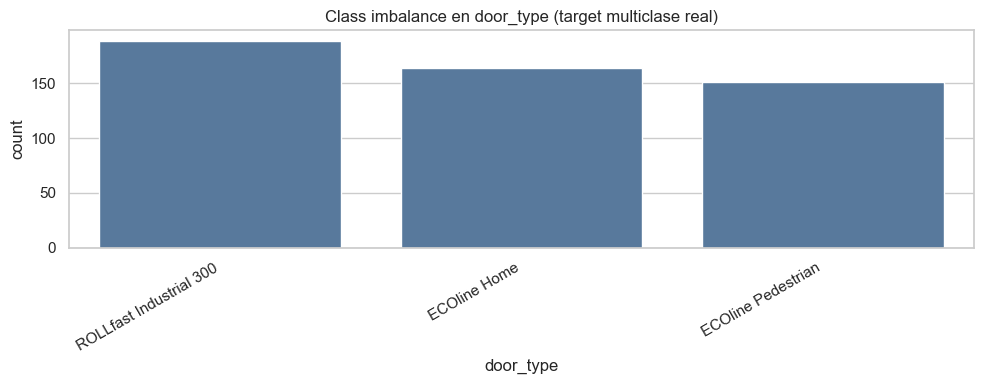

Imbalance ratio door_type: 1.25


In [117]:
# Distribucion de la variable objetivo principal (multiclase real)
# Primer chequeo de imbalance del target real para anticipar sesgos de entrenamiento.
plt.figure(figsize=(10, 4))
door_counts = doors_registry["door_type"].value_counts()
sns.barplot(x=door_counts.index, y=door_counts.values, color="#4C78A8")
plt.xticks(rotation=30, ha="right")
plt.title("Class imbalance en door_type (target multiclase real)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

imbalance_ratio = door_counts.max() / max(door_counts.min(), 1)
print(f"Imbalance ratio door_type: {imbalance_ratio:.2f}")


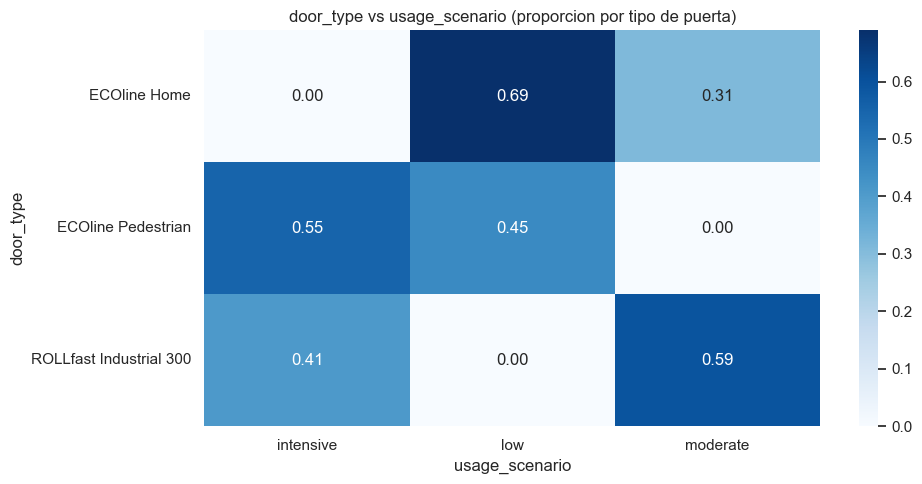

In [118]:
# Analisis explainability temprano: asociaciones simples entre categoricas clave
# El heatmap normalizado por fila ayuda a interpretar la mezcla de escenarios por tipo de puerta.
ct = pd.crosstab(doors_registry["door_type"], doors_registry["usage_scenario"], normalize="index")
plt.figure(figsize=(10, 5))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues")
plt.title("door_type vs usage_scenario (proporcion por tipo de puerta)")
plt.tight_layout()
plt.show()


In [119]:
# Join temprano para EDA integrado
# Unificamos etiquetas para que el merge con catalog no pierda filas por diferencias semanticas.
doors_registry["installation_environment"] = doors_registry["installation_environment"].replace(
    "Community", "Residential Community"
)

# Este dataframe combinado es la base para analizar riesgo, imputacion y proxy targets.
eda_merged = doors_registry.merge(maintenance_history, on="door_id", how="left")
eda_merged = eda_merged.merge(
    door_catalog,
    on=["door_type", "usage_scenario", "installation_environment"],
    how="left"
)

# Fecha de corte fija para tener calculos reproducibles entre ejecuciones.
eda_merged["last_maintenance_date"] = pd.to_datetime(eda_merged["last_maintenance_date"], errors="coerce")
snapshot_date = pd.Timestamp("2025-01-01")
eda_merged["days_since_maintenance"] = (snapshot_date - eda_merged["last_maintenance_date"]).dt.days


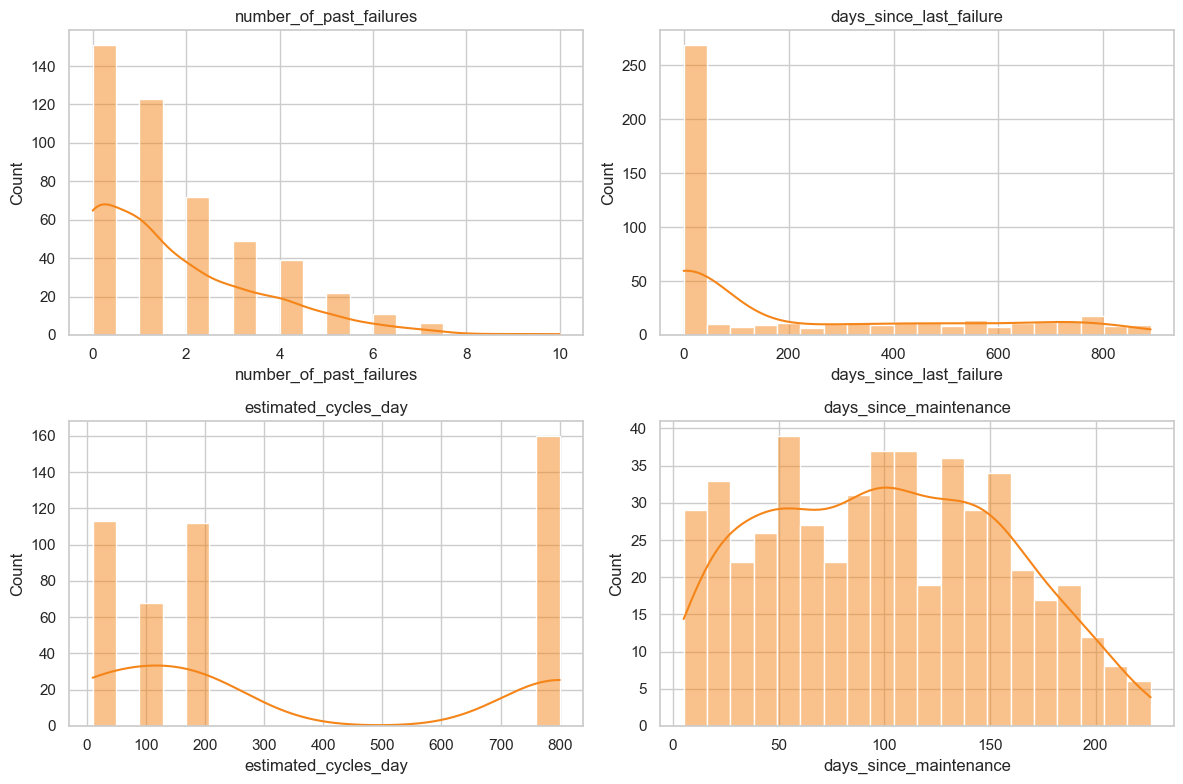

In [120]:
# Distribuciones numericas importantes para imputacion y riesgo
num_for_eda = [
    "number_of_past_failures",
    "days_since_last_failure",
    "estimated_cycles_day",
    "days_since_maintenance",
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(num_for_eda):
    sns.histplot(eda_merged[col], bins=20, kde=True, ax=axes[i], color="#F58518")
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


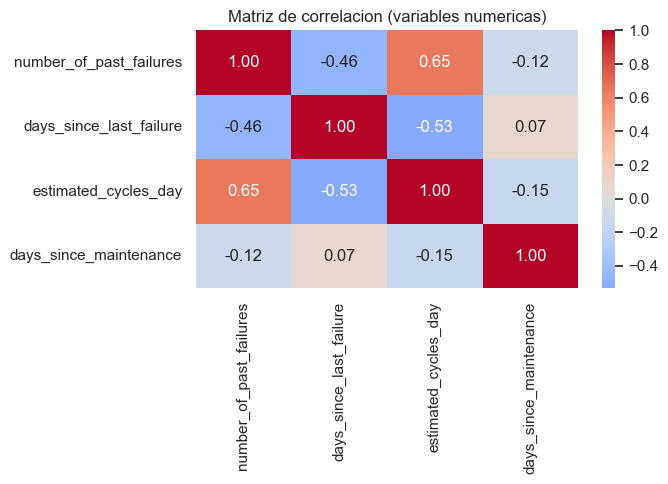

In [99]:
# Correlacion para apoyar decisiones de explainability
# No implica causalidad, pero orienta sobre variables con señal conjunta fuerte.
corr_cols = ["number_of_past_failures", "days_since_last_failure", "estimated_cycles_day", "days_since_maintenance"]
plt.figure(figsize=(7, 5))
sns.heatmap(eda_merged[corr_cols].corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlacion (variables numericas)")
plt.tight_layout()
plt.show()


### 3.6) Time series analysis and forecasting (baseline)
Usamos `last_maintenance_date` para crear una serie temporal mensual de actividad de mantenimiento.
Luego comparamos dos baselines simples de forecasting (naive y rolling mean) para tener una referencia temporal interpretable.


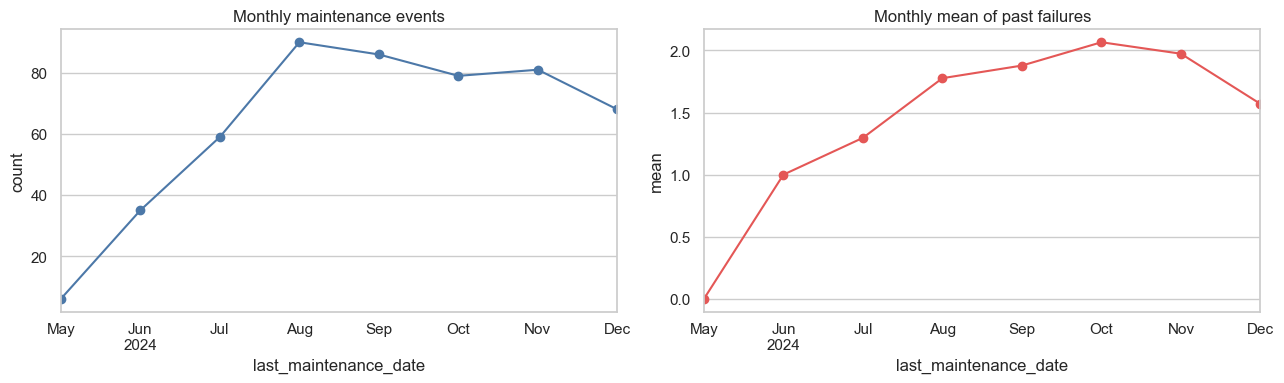

In [100]:
# Serie temporal mensual de eventos de mantenimiento.
ts_history = maintenance_history[["last_maintenance_date", "number_of_past_failures"]].copy()
ts_history["last_maintenance_date"] = pd.to_datetime(ts_history["last_maintenance_date"], errors="coerce")
ts_history = ts_history.dropna(subset=["last_maintenance_date"]).sort_values("last_maintenance_date")

monthly_events = (
    ts_history.set_index("last_maintenance_date")
    .resample("MS")
    .size()
    .rename("maintenance_events")
)

monthly_failures_mean = (
    ts_history.set_index("last_maintenance_date")["number_of_past_failures"]
    .resample("MS")
    .mean()
    .rename("avg_past_failures")
)

monthly_ts = pd.concat([monthly_events, monthly_failures_mean], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
monthly_ts["maintenance_events"].plot(ax=axes[0], marker="o", color="#4C78A8")
axes[0].set_title("Monthly maintenance events")
axes[0].set_ylabel("count")

monthly_ts["avg_past_failures"].plot(ax=axes[1], marker="o", color="#E45756")
axes[1].set_title("Monthly mean of past failures")
axes[1].set_ylabel("mean")

plt.tight_layout()
plt.show()


,model,mae,rmse
0,naive_last_value,6.5,7.905694
1,rolling_mean_3,10.5,12.349089


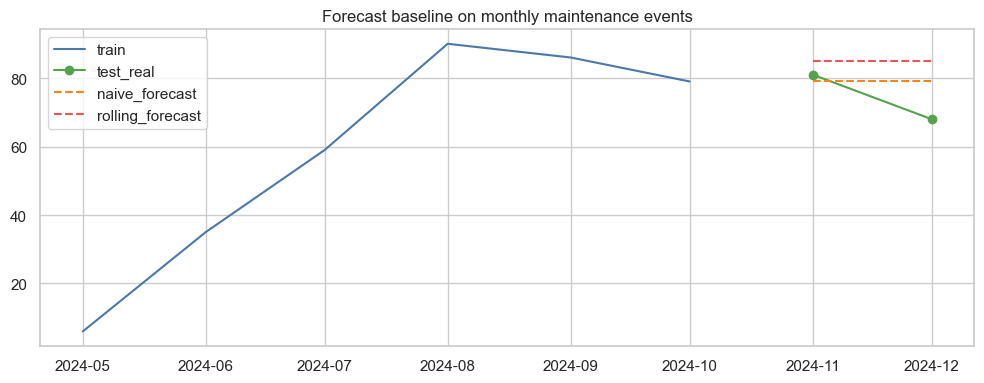

In [101]:
# Forecasting baseline sobre monthly_events.
# Se usa split temporal (sin barajar) para respetar el orden cronologico.
time_series_metrics = {}
series = monthly_ts["maintenance_events"].dropna()

if len(series) >= 8:
    split_idx = int(len(series) * 0.8)
    split_idx = max(split_idx, 4)
    train_ts, test_ts = series.iloc[:split_idx], series.iloc[split_idx:]

    if len(test_ts) > 0:
        # Naive: predice siempre el ultimo valor observado en train.
        naive_pred = pd.Series(train_ts.iloc[-1], index=test_ts.index)

        # Rolling mean: media movil de los ultimos 3 periodos de train.
        roll_window = min(3, len(train_ts))
        rolling_pred = pd.Series(train_ts.tail(roll_window).mean(), index=test_ts.index)

        # Metricas de error para comparar baselines de forecasting.
        naive_mae = mean_absolute_error(test_ts, naive_pred)
        naive_rmse = float(np.sqrt(mean_squared_error(test_ts, naive_pred)))

        rolling_mae = mean_absolute_error(test_ts, rolling_pred)
        rolling_rmse = float(np.sqrt(mean_squared_error(test_ts, rolling_pred)))

        ts_results = pd.DataFrame([
            {"model": "naive_last_value", "mae": naive_mae, "rmse": naive_rmse},
            {"model": "rolling_mean_3", "mae": rolling_mae, "rmse": rolling_rmse},
        ]).sort_values("mae")

        display(ts_results)

        best_ts = ts_results.iloc[0]
        time_series_metrics = {
            "best_model": best_ts["model"],
            "mae": float(best_ts["mae"]),
            "rmse": float(best_ts["rmse"]),
            "n_train": int(len(train_ts)),
            "n_test": int(len(test_ts)),
        }

        # Visual comparativa forecast vs real en tramo de test.
        plt.figure(figsize=(10, 4))
        plt.plot(train_ts.index, train_ts.values, label="train", color="#4C78A8")
        plt.plot(test_ts.index, test_ts.values, label="test_real", color="#54A24B", marker="o")
        plt.plot(test_ts.index, naive_pred.values, label="naive_forecast", linestyle="--", color="#F58518")
        plt.plot(test_ts.index, rolling_pred.values, label="rolling_forecast", linestyle="--", color="#E45756")
        plt.title("Forecast baseline on monthly maintenance events")
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("No hay tramo de test temporal suficiente para forecasting.")
else:
    print("Serie temporal demasiado corta para evaluar forecasting con split temporal.")

## 4) Data Transformation
In this step we will perform the necessary data transformations to prepare our dataset for modeling. This includes handling missing values, encoding categorical variables, and creating new features if necessary.

In [102]:

# In doors_registry, some doors are labeled as Community. How ever in  door_type_usage_catalog, that same environment is labeled as Residential Community.
doors_registry["installation_environment"] = doors_registry["installation_environment"].replace("Community", "Residential Community")


### 4.1) Join

In [103]:
merged_data = doors_registry.merge(maintenance_history, on='door_id', how='left')

# Join with Catalog on the three environment keys
final_dataset = merged_data.merge(
    door_catalog,
    on=['door_type','usage_scenario', 'installation_environment'],
    how='left'
)
# Drop unnecessary columns
# Remove the cols : days_to_next_failure,failed_next_30_days becuase it has 100 % of missing data
final_dataset.drop(
    columns=['door_id','country_id',"days_to_next_failure", "failed_next_30_days" , "last_maintenance_date" ],
    inplace=True)


### 4.2) Dependency analysis and feature selection
In this step we will analyze the dependencies between our features to identify any strong correlations or associations. This will help us to select the most relevant features for our model and to avoid multicollinearity issues. We will use correlation analysis for numerical features and Cramér's V for categorical features to measure the strength of associations. Based on the results, we will decide which features to keep, which ones to drop, and if any feature engineering is needed to create new features that may capture important information for our classification task. The goal is to have a set of features that are informative, non-redundant, and suitable for training our machine learning model effectively.

Numerical cols: 3
Categorical cols: 2


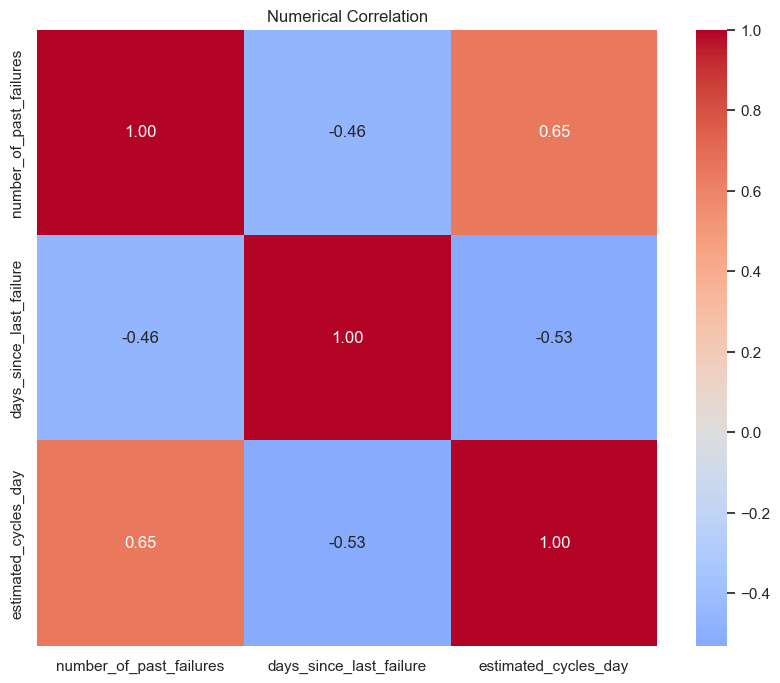

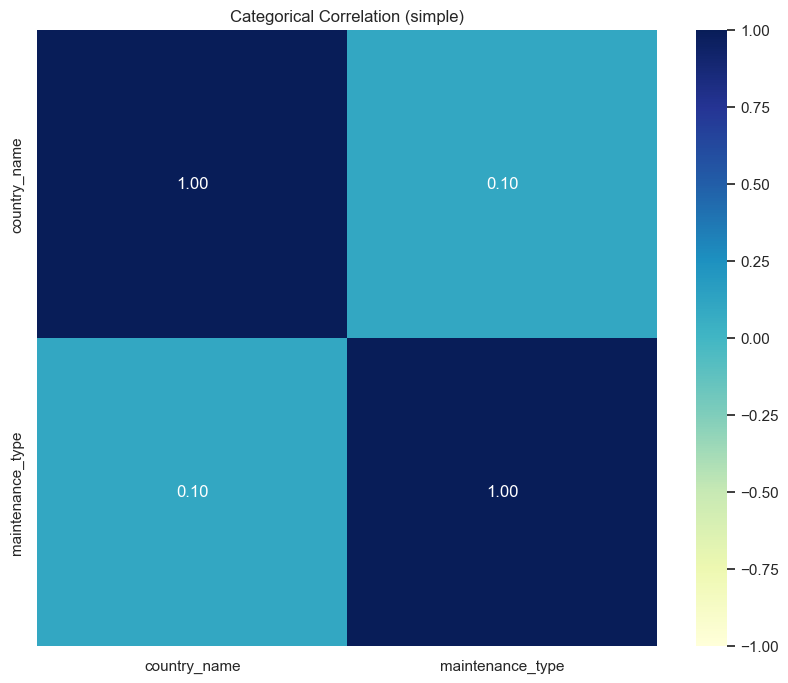

Review these two heatmaps manually and choose columns to keep/drop.


In [135]:

target_col = "door_type"
feature_df = final_dataset.drop(columns=[target_col], errors="ignore")

num_cols = feature_df.select_dtypes(include=["number"]).columns.tolist()
cat_cols = feature_df.select_dtypes(include=["str", "category", "bool"]).columns.tolist()

print(f"Numerical cols: {len(num_cols)}")
print(f"Categorical cols: {len(cat_cols)}")

# 1) Numerical correlation heatmap with values
if num_cols:
    num_corr = feature_df[num_cols].corr().round(2)
    plt.figure(figsize=(10, 8))
    sns.heatmap(num_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Numerical Correlation")
    plt.show()


# 2) Categorical correlation heatmap (simple version)
if cat_cols:
    cat_df = feature_df[cat_cols].copy()

    # Convert each categorical column to integer codes
    for col in cat_cols:
        cat_df[col] = pd.factorize(cat_df[col])[0]

    cat_corr = cat_df.corr().round(2)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cat_corr, annot=True, fmt=".2f", cmap="YlGnBu", vmin=-1, vmax=1)
    plt.title("Categorical Correlation (simple)")
    plt.show()

print("Review these two heatmaps manually and choose columns to keep/drop.")

In [105]:
drop_features = [
    'context_criticality_id',
    'criticality_level',
    'customer_type',
    'installation_environment',
    'maintenance_intensity',
    'operational_complexity',
    'usage_scenario']
final_dataset = final_dataset.drop(columns=drop_features, errors="ignore")

In [106]:
final_dataset.head()

,country_name,door_type,maintenance_type,number_of_past_failures,days_since_last_failure,estimated_cycles_day
0,Spain,ECOline Pedestrian,Inspection,0.0,569.0,120.0
1,Spain,ECOline Pedestrian,Preventive,0.0,715.0,120.0
2,Spain,ECOline Pedestrian,Inspection,3.0,0.0,120.0
3,Spain,ECOline Pedestrian,Inspection,0.0,1.0,120.0
4,Spain,ECOline Pedestrian,Inspection,2.0,2.0,120.0


### 4.2) Encode categorical variables

In [130]:

target_col = "door_type"
X = final_dataset.drop(columns=[target_col])
y = final_dataset[target_col]

cat_cols = X.select_dtypes(include=["str", "category"]).columns.tolist()

X = pd.get_dummies(
    X,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)


### 4.3) Split train - test

In [129]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(403, 25) (403,)
(101, 25) (101,)


### 4.4 ) Handle missing values
Because we have more than one variable with null values , we will use Multivariate imputation methods . This are the different techniques that we will use , and see which one works better for our datasets :

   - Multivariate Imputation by Chained Equations (MICE): This technique models each feature with missing values as a function of other features and iteratively imputes missing values. It can capture complex relationships and is suitable for both numerical and categorical data but can be computationally intensive.

   - MissForest Imputation: This method uses Random Forest models in an iterative way to impute missing values. For each column with missing data, it trains a model using the other columns as predictors and then fills the missing entries. It works well with mixed data types (numerical and categorical), captures non-linear relationships, and is often more accurate than simple imputation methods. However, it can be computationally expensive on larger datasets.


   - K-Nearest Neighbors (KNN) Imputation: This method imputes missing values based on the values of the nearest neighbors in the feature space. It can capture complex relationships between features but can be computationally expensive for large datasets.




In [136]:

def mean_imputation(train: pd.DataFrame, test: pd.DataFrame):
    imputer = SimpleImputer(strategy="mean")
    train_imp = pd.DataFrame(imputer.fit_transform(train), columns=train.columns, index=train.index)
    test_imp = pd.DataFrame(imputer.transform(test), columns=test.columns, index=test.index)
    return train_imp, test_imp


def median_imputation(train: pd.DataFrame, test: pd.DataFrame):
    imputer = SimpleImputer(strategy="median")
    train_imp = pd.DataFrame(imputer.fit_transform(train), columns=train.columns, index=train.index)
    test_imp = pd.DataFrame(imputer.transform(test), columns=test.columns, index=test.index)
    return train_imp, test_imp


def forward_fill_imputation(train: pd.DataFrame, test: pd.DataFrame):
    # ffill/bfill evita NaN residuales cuando hay huecos al inicio/fin.
    train_imp = train.ffill().bfill()
    test_imp = test.ffill().bfill()
    return train_imp, test_imp


def backward_fill_imputation(train: pd.DataFrame, test: pd.DataFrame):
    train_imp = train.bfill().ffill()
    test_imp = test.bfill().ffill()
    return train_imp, test_imp


def mic_imputation(train: pd.DataFrame , test : pd.DataFrame):
    imputer_mice = IterativeImputer(random_state=RANDOM_STATE)
    train_mice = pd.DataFrame(
        imputer_mice.fit_transform(train),
        columns=train.columns,
        index=train.index)
    test_mice = pd.DataFrame(
        imputer_mice.transform(test),
        columns= test.columns,
        index=test.index)
    return train_mice , test_mice


def forest_mic_imputation(train: pd.DataFrame , test : pd.DataFrame):
    if not MISSFOREST_AVAILABLE:
        raise RuntimeError("MissForest no disponible en el entorno.")

    mf_cls = importlib.import_module("missforest").MissForest
    imputer_forest = mf_cls()
    train_mic_forest = pd.DataFrame(
        imputer_forest.fit_transform(train),
        columns=train.columns,
        index=train.index)
    test_mic_forest = pd.DataFrame(
        imputer_forest.transform(test),
        columns= test.columns,
        index=test.index)
    return train_mic_forest , test_mic_forest


def knn_imputation(train: pd.DataFrame , test : pd.DataFrame):
    imputer_knn = KNNImputer()
    train_knn = pd.DataFrame(
        imputer_knn.fit_transform(train),
        columns=train.columns,
        index=train.index)
    test_knn = pd.DataFrame(
        imputer_knn.transform(test),
        columns= test.columns,
        index=test.index)
    return train_knn , test_knn

### Results

In [137]:

AVAILABLE_IMPUTERS = {
    "MICE": mic_imputation,
    "KNN": knn_imputation,
    "mean": mean_imputation,
    "median": median_imputation,
    "forward_fill": forward_fill_imputation,
    "backward_fill": backward_fill_imputation,
}
if MISSFOREST_AVAILABLE:
    AVAILABLE_IMPUTERS["MissForest"] = forest_mic_imputation

# Estrategias por defecto para este notebook (comparacion corta y estable).
imputation_strategies = {
    "MICE": AVAILABLE_IMPUTERS["MICE"],
    "KNN": AVAILABLE_IMPUTERS["KNN"],
}
if MISSFOREST_AVAILABLE:
    imputation_strategies["MissForest"] = AVAILABLE_IMPUTERS["MissForest"]

# Alias de compatibilidad: evita NameError si alguien usa `strategies` en vez de `imputation_strategies`.
strategies = imputation_strategies


def resolve_imputation_strategies(strategies_input=None):
    if strategies_input is None:
        return imputation_strategies

    if isinstance(strategies_input, dict):
        return strategies_input

    if isinstance(strategies_input, (list, tuple, set)):
        unknown = [name for name in strategies_input if name not in AVAILABLE_IMPUTERS]
        if unknown:
            raise ValueError(f"Estrategias desconocidas: {unknown}. Disponibles: {list(AVAILABLE_IMPUTERS.keys())}")
        return {name: AVAILABLE_IMPUTERS[name] for name in strategies_input}

    raise TypeError("`strategies` debe ser dict, list/tuple/set o None.")


# Imputacion: comparamos estrategias bajo el mismo modelo para aislar el impacto del imputador.
def evaluate_imputation(X_train=None, y_train=None, X_test=None, y_test=None, strategies=None):
    if X_train is None:
        X_train = globals().get("X_train")
    if y_train is None:
        y_train = globals().get("y_train")
    if X_test is None:
        X_test = globals().get("X_test")
    if y_test is None:
        y_test = globals().get("y_test")

    if any(v is None for v in [X_train, y_train, X_test, y_test]):
        raise ValueError("Faltan argumentos: pasa X_train, y_train, X_test, y_test o ejecuta primero el split train/test.")

    strategies_dict = resolve_imputation_strategies(strategies)
    results = []

    for name, imputer_fn in strategies_dict.items():
        X_tr_imp, X_te_imp = imputer_fn(X_train, X_test)

        model = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
        model.fit(X_tr_imp, y_train)

        y_pred = model.predict(X_te_imp)
        results.append({
            "strategy": name,
            "f1_score": f1_score(y_test, y_pred, average="macro"),
        })

    return pd.DataFrame(results)

In [111]:
X_train.head()

,number_of_past_failures,days_since_last_failure,estimated_cycles_day,country_name_Brazil,country_name_Canada,country_name_Chile,country_name_China,country_name_Egypt,country_name_France,country_name_Germany,...,country_name_Poland,country_name_Portugal,country_name_South Africa,country_name_Spain,country_name_Turkey,country_name_United Kingdom,country_name_United States,maintenance_type_Inspection,maintenance_type_Major Repair,maintenance_type_Preventive
92,3.0,NaN,800.0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
183,1.0,269.0,200.0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
437,4.0,0.0,800.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
387,4.0,0.0,800.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
377,3.0,670.0,200.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,0


In [138]:
imputation_results_df = evaluate_imputation(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    strategies=imputation_strategies,
)

if imputation_results_df.empty:
    print("Error: imputation_results_df esta vacio")
    print("Verifica la funcion evaluate_imputation()")
else:
    print("Columnas disponibles:", imputation_results_df.columns.tolist())
    print(imputation_results_df)

    #

Columnas disponibles: ['strategy', 'f1_score']
  strategy  f1_score
0     MICE  0.784892
1      KNN  0.775957


## 4.5 ) Choosing best imputation strategy
Based on the results of our imputation strategies, we will select the one that yields the best performance on our evaluation metrics. This will be the imputation method we will use for the next steps in our analysis. We will also analyze the impact of the chosen imputation method on the distribution of our features and the target variable to ensure that it does not introduce bias or distort the data in a way that could affect our model's performance.

In [139]:
best_imputation_strategy = imputation_results_df.sort_values(by="f1_score", ascending=False)["strategy"][0]
print(f"Best imputation strategy: {best_imputation_strategy}")

imputation_funct = imputation_strategies[best_imputation_strategy]

X_train, X_test = imputation_funct(X_train, X_test)

print(X_train.isnull().sum())

Best imputation strategy: MICE
number_of_past_failures          0
days_since_last_failure          0
estimated_cycles_day             0
country_name_Brazil              0
country_name_Canada              0
country_name_Chile               0
country_name_China               0
country_name_Egypt               0
country_name_France              0
country_name_Germany             0
country_name_India               0
country_name_Italy               0
country_name_Japan               0
country_name_Mexico              0
country_name_Morocco             0
country_name_Poland              0
country_name_Portugal            0
country_name_South Africa        0
country_name_Spain               0
country_name_Turkey              0
country_name_United Kingdom      0
country_name_United States       0
maintenance_type_Inspection      0
maintenance_type_Major Repair    0
maintenance_type_Preventive      0
dtype: int64


## 4.6) Under Sampling & Over Sampling
In this step we will apply under sampling and over sampling techniques to handle the class imbalance in our dataset. Under sampling involves reducing the number of samples in the majority class, while over sampling involves increasing the number of samples in the minority class. We will compare the performance of our models using these techniques to see which one works better for our dataset.

In [140]:
sampling_strategies = {"baseline": None}
if IMBLEARN_AVAILABLE:
    sampling_strategies.update({
        "ENN (Under-sampling)": importlib.import_module("imblearn.under_sampling").EditedNearestNeighbours(),
        "SMOTE (Over-sampling)": importlib.import_module("imblearn.over_sampling").SMOTE(random_state=RANDOM_STATE),
        "SMOTEENN (Combined)": importlib.import_module("imblearn.combine").SMOTEENN(random_state=RANDOM_STATE),
    })
else:
    print("imblearn no disponible: se evalua solo baseline en sampling.")

def evaluate_sampling(X_train, y_train, X_test, y_test, strategies):
    results = []

    for name, sampler in strategies.items():
        if sampler is None:
            X_res, y_res = X_train, y_train
        else:
            X_res, y_res = sampler.fit_resample(X_train, y_train)

        model = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
        model.fit(X_res, y_res)

        y_pred = model.predict(X_test)

        results.append({
            "strategy": name,
            "accuracy": accuracy_score(y_test, y_pred),
            "f1_macro": f1_score(y_test, y_pred, average="macro"),
        })

    return pd.DataFrame(results)


imblearn no disponible: se evalua solo baseline en sampling.


### Resuts

In [142]:
results_df= evaluate_sampling(X_train, y_train, X_test, y_test, sampling_strategies)

results_df

,strategy,accuracy,f1_macro
0,baseline,0.782178,0.784892


### 4.6.1) Choosing best sampling strategy
Based on the results of our sampling strategies, we will select the one that yields the best performance on our evaluation metrics. This will be the sampling method we will use for the next steps in our analysis. We will also analyze the impact of the chosen sampling method on the distribution of our features and the target variable to ensure that it does not introduce bias or distort the data in a way that could affect our model's performance. Additionally, we will consider the computational cost and complexity of the sampling method, as some techniques may be more resource-intensive than others, especially when dealing with large datasets. Ultimately, our goal is to find a sampling strategy that effectively addresses the class imbalance while maintaining or improving the overall performance of our classification model.

In [143]:
best_sampling_strategy = results_df.sort_values(by="f1_macro", ascending=False)["strategy"][0]
print(f"Best sampling strategy: {best_sampling_strategy}")

sampling_func = sampling_strategies[best_sampling_strategy]

if sampling_func is not None and hasattr(sampling_func, "fit_resample"):
    X_train, y_train = sampling_func.fit_resample(X_train, y_train)


Best sampling strategy: baseline


## 5) Multi Class Classification
In this step we compare multiclass strategies depending on whether the base model outputs probabilities or not.

In [144]:
multiclass_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_STATE,
        class_weight="balanced",
    ),
    "One-vs-Rest": OneVsRestClassifier(LinearSVC(random_state=RANDOM_STATE)),
    "One-vs-One": OneVsOneClassifier(LinearSVC(random_state=RANDOM_STATE)),
}


def evaluate_multiclass_strategies(models, X_train, y_train, X_test, y_test):
    rows = []

    for name, model in models.items():

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        rows.append(
            {
                "strategy": name,
                "accuracy": accuracy_score(y_test, y_pred)
            }
        )

    return pd.DataFrame(rows)




### Results

In [145]:
multiclass_results_df = evaluate_multiclass_strategies(
    multiclass_models,
    X_train,
    y_train,
    X_test,
    y_test,
)

multiclass_results_df

C:\Users\lucas.stille\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,strategy,accuracy
0,Logistic Regression,0.564356
1,One-vs-Rest,0.524752
2,One-vs-One,0.574257


## 6) Conclusiones automáticas del EDA
Resumen corto de hallazgos clave para justificar decisiones de imputación, balanceo y modelado.


In [146]:
# Reutilizamos métricas ya calculadas en el notebook para generar conclusiones accionables.
conclusions = []

# 1) Missingness (foco en variables con más impacto potencial)
try:
    max_missing_history = float(miss_history["missing_pct"].max())
    conclusions.append(
        f"Missingness: en `maintenance_history` el máximo de nulos es {max_missing_history:.1f}%. "
        "Esto justifica comparar imputadores multivariantes (MICE/KNN/MissForest) antes del modelo final."
    )
except Exception:
    pass

# 2) Imbalance del target multiclase real
try:
    conclusions.append(
        f"Imbalance multiclase (`door_type`): ratio mayor/minor = {imbalance_ratio:.2f}. "
        "Conviene priorizar `f1_macro` sobre accuracy y evaluar estrategias de resampling."
    )
except Exception:
    pass

# 3) Señales explainability de variables operativas
try:
    corr_abs = eda_merged[corr_cols].corr(numeric_only=True).abs()
    np.fill_diagonal(corr_abs.values, 0)
    top_pair = corr_abs.stack().idxmax()
    top_val = corr_abs.stack().max()
    conclusions.append(
        f"Relación numérica más fuerte: `{top_pair[0]}` vs `{top_pair[1]}` (|corr|={top_val:.2f}). "
        "Puede ser una señal clave para interpretabilidad global y análisis de importancia."
    )
except Exception:
    pass

# 4) Proxy targets para escenarios sin label real de fallo
try:
    bin_counts = eda_merged["target_binary_proxy"].value_counts()
    bin_ir = bin_counts.max() / max(bin_counts.min(), 1)
    mc_counts = eda_merged["target_multiclass_proxy"].value_counts()
    mc_ir = mc_counts.max() / max(mc_counts.min(), 1)
    conclusions.append(
        f"Proxy targets: binario IR={bin_ir:.2f} y multiclase IR={mc_ir:.2f}. "
        "Son útiles para experimentar explainability/imbalance cuando `failed_next_30_days` no tiene labels."
    )
except Exception:
    pass

# 5) Multi-label support (densidad de eventos)
try:
    ml_support = multilabel_targets.drop(columns=["door_id"]).sum()
    mean_labels = float(multilabel_targets.drop(columns=["door_id"]).sum(axis=1).mean())
    top_label = ml_support.sort_values(ascending=False).index[0]
    conclusions.append(
        f"Multi-label: media de etiquetas por muestra = {mean_labels:.2f}; etiqueta más frecuente: `{top_label}`. "
        "Esto sugiere co-ocurrencia de eventos y valida un enfoque One-vs-Rest para multilabel."
    )
except Exception:
    pass

# 6) Time series forecasting baseline
try:
    if time_series_metrics:
        conclusions.append(
            f"Forecasting temporal: mejor baseline `{time_series_metrics['best_model']}` "
            f"(MAE={time_series_metrics['mae']:.2f}, RMSE={time_series_metrics['rmse']:.2f}) "
            f"con split temporal train/test de {time_series_metrics['n_train']}/{time_series_metrics['n_test']} meses."
        )
except Exception:
    pass

# Fallback para garantizar salida clara incluso si alguna celda previa no se ejecutó.
if not conclusions:
    conclusions.append(
        "No se pudieron consolidar métricas automáticas. Ejecuta el notebook de arriba abajo para regenerar conclusiones."
    )

print("Conclusiones automáticas (EDA):")
for i, c in enumerate(conclusions[:5], 1):
    print(f"{i}. {c}")


Conclusiones automáticas (EDA):
1. Missingness: en `maintenance_history` el máximo de nulos es 100.0%. Esto justifica comparar imputadores multivariantes (MICE/KNN/MissForest) antes del modelo final.
2. Imbalance multiclase (`door_type`): ratio mayor/minor = 1.25. Conviene priorizar `f1_macro` sobre accuracy y evaluar estrategias de resampling.
